In [21]:
import chainladder as cl


In [22]:
# Load Data
clrd = cl.load_sample("clrd").groupby("LOB").sum()
X = clrd.loc["medmal", "CumPaidLoss"]
sample_weight = clrd.loc["medmal", "EarnedPremDIR"].latest_diagonal

# Specify Model
grid = cl.GridSearch(
    estimator=cl.Pipeline(
        steps=[
            ("dev", cl.Development()),
            ("tail", cl.TailCurve()),
            ("model", cl.Benktander()),
        ]
    ),
    param_grid=dict(
        model__n_iters=list(range( 1, 100)), model__apriori=[0.01, 100, 250] #250 (bombA) to katastrofa n_iters = 1 -> wierzę swojemu zgadywaniu
    ),
    scoring={"IBNR": lambda x: x.named_steps.model.ibnr_.sum()},
    n_jobs=-1,
)

In [23]:
from sklearn import set_config

set_config(display="diagram")
grid

,estimator,Pipeline(step...enktander())])
,param_grid,"{'model__apriori': [0.01, 100, ...], 'model__n_iters': [1, 2, ...]}"
,scoring,{'IBNR': <function <la...00136788318A0>}
,n_jobs,-1
,verbose,0
,error_score,'raise'
,n_periods,-1
,average,'volume'
,sigma_interpolation,'log-linear'
,drop,None
,drop_high,None


In [24]:
# Fit Model
grid.fit(X, sample_weight=sample_weight)

# Analyze results
output = grid.results_.pivot(
    index="model__n_iters", columns="model__apriori", values="IBNR"
)
output.head()

model__apriori,0.01,100.00,250.00
model__n_iters,,,
1,16653.143125,1.665314e+08,4.163286e+08
2,463676.853536,1.096296e+08,2.733948e+08
3,656297.727485,8.618811e+07,2.144987e+08
4,767072.371697,7.283225e+07,1.809408e+08
5,840855.176040,6.396460e+07,1.586597e+08


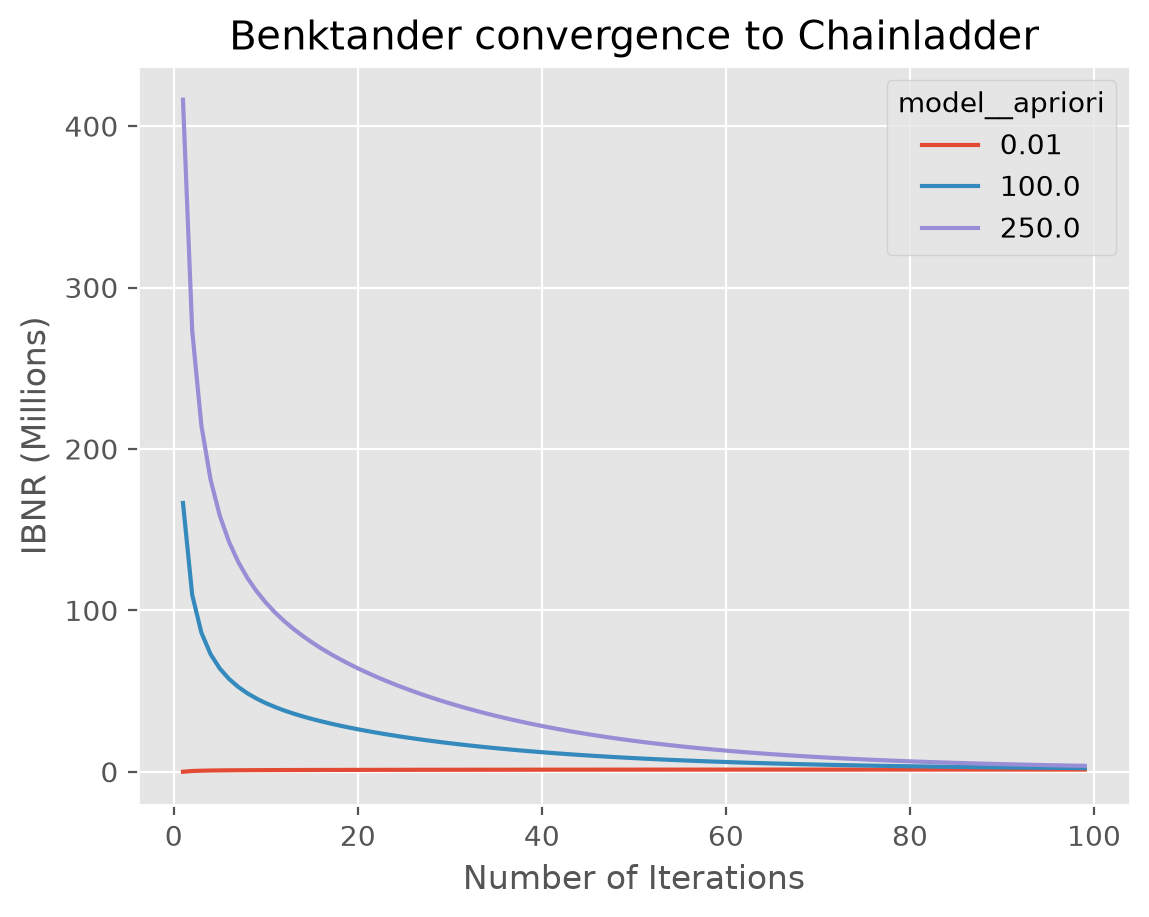

In [25]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")
%config InlineBackend.figure_format = 'retina'

ax = (output / 1e6).plot(
    ylabel="IBNR (Millions)",
    xlabel="Number of Iterations",
    title="Benktander convergence to Chainladder",
)